In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV

In [2]:
# draw classification regions function

def draw_classification_regions(X,y,model):
    
    # classes 
    classes = model.classes_
    # feature names
    try:
        feature_names = X.columns
    except:
        feature_names = ['feature #1','feature #2']
    
    # put data into numpy arrays
    try:
        X = np.array(X)
        y = np.array(y).flatten()
    except:
        print('something went wrong')
    
    from matplotlib.colors import ListedColormap
    # create a mesh grid
    h = .01
    x_min, x_max = X[:, 0].min() - .1, X[:, 0].max() + .1
    y_min, y_max = X[:, 1].min() - .1, X[:, 1].max() + .1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # evaluate classifier at all mesh grid points
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # number of classes
    n_classes = len(np.unique(y))
    
    # map classes to 0,1,2
    for i in range(n_classes):
        Z[Z==classes[i]]=i

    # Put the result into a color plot
    fig, ax = plt.subplots(figsize=(10,5))
    colors = ['C0','C1','C2']
    if n_classes==3:
        custom_cmap = ListedColormap(['#9898ff','#fafab0','#a0faa0'])
    else:
        custom_cmap = ListedColormap(['#9898ff','#fafab0'])
        
    ax.contourf(xx, yy, Z, cmap=custom_cmap)

    # plot dataset
    for i in range(n_classes):
        ax.scatter(X[y==classes[i],0], X[y==classes[i],1], c = colors[i], label=classes[i], s=75, alpha=0.8)

    ax.set_xlabel(feature_names[0], fontsize=15)
    ax.set_ylabel(feature_names[1], fontsize=15)

    ax.legend()

## Example 1

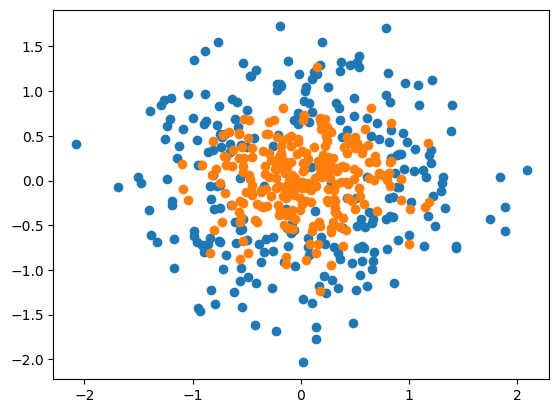

In [5]:
from sklearn.datasets import make_circles
X,y = make_circles(n_samples=500, factor=0.1, noise = 0.4)
plt.scatter(X[y==0,0], X[y==0,1])
plt.scatter(X[y==1,0], X[y==1,1])

In [6]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X,y)

In [12]:
tree = DecisionTreeClassifier(max_depth=2)
tree.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=2)

In [13]:
y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)

In [14]:
accuracy_score(y_train, y_train_pred)

0.7653333333333333

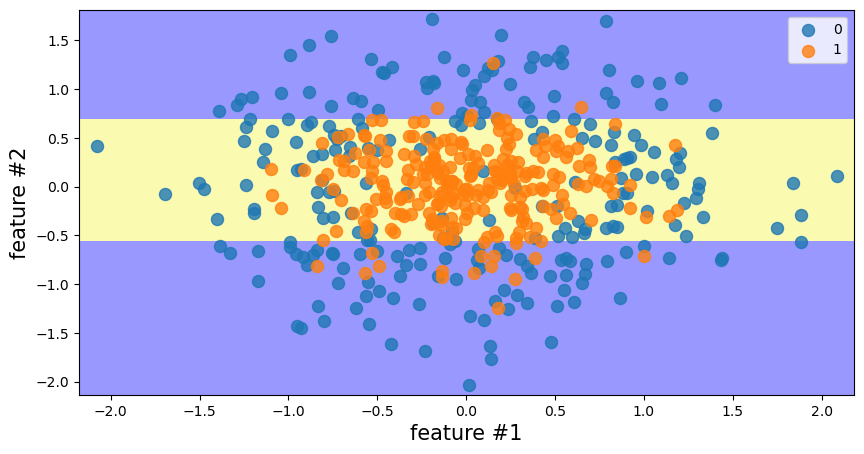

In [15]:
draw_classification_regions(X,y,tree)

In [17]:
random_forest = RandomForestClassifier(n_estimators=300, # number of trees
                                        max_depth=2, # max depth of each tree
                                        n_jobs=-1 # use all CPUs 
                                        )
random_forest.fit(X_train,y_train)

RandomForestClassifier(max_depth=2, n_estimators=300, n_jobs=-1)

In [18]:
y_train_pred = random_forest.predict(X_train)
y_test_pred = random_forest.predict(X_test)

In [20]:
accuracy_score(y_train, y_train_pred)

0.8453333333333334

In [22]:
accuracy_score(y_test, y_test_pred)

0.776

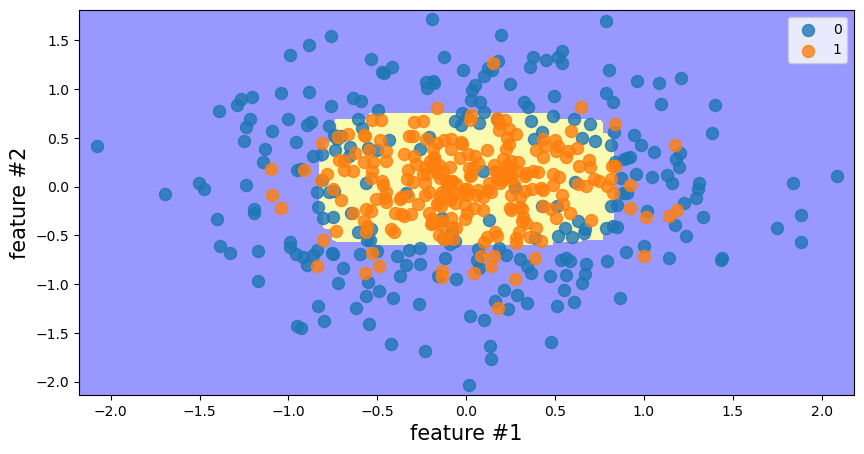

In [23]:
draw_classification_regions(X,y,random_forest)

## Grid Search

In [24]:
url = 'https://raw.githubusercontent.com/um-perez-alvaro/Data-Science-Practice/master/Data/iris.csv'
data=pd.read_csv(url)

In [25]:
data

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


Goal: predict species given other columns

In [26]:
data.species.value_counts()

Iris-versicolor    50
Iris-virginica     50
Iris-setosa        50
Name: species, dtype: int64

In [27]:
X = data.drop('species', axis=1)
y = data.species

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X,y)

In [30]:
# grid search
params_dict = {'n_estimators':[10,50,100,200],
              'max_depth': [2,3,4,5],
              'min_samples_leaf':[1,2,4,8],
              'min_samples_split':[2,4,8]}

grid = GridSearchCV(random_forest,
                   params_dict,
                   cv=5,
                   scoring='accuracy',
                   n_jobs=-1)

grid.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=RandomForestClassifier(max_depth=2, n_estimators=300,
                                              n_jobs=-1),
             n_jobs=-1,
             param_grid={'max_depth': [2, 3, 4, 5],
                         'min_samples_leaf': [1, 2, 4, 8],
                         'min_samples_split': [2, 4, 8],
                         'n_estimators': [10, 50, 100, 200]},
             scoring='accuracy')

In [31]:
best_rf = grid.best_estimator_
y_test_pred = best_rf.predict(X_test)

accuracy_score(y_test,y_test_pred)

0.9736842105263158